In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
import seaborn as sns
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE
from src.accuracy import max_value_diff
from src.utils import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
# load matched data different keys
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
match_types = [
    "ws6qt-ws5ql-geo-valuepre-strict-nans",
    "by_labelled_ws_quanti_optqt-ws_quali_optql-geo-valuepre-loose-nans",
    "ws6qt-ws5ql-geo-valuepre-strict-nans",
]
model = "meta-llama_llama-4-scout-17b-16e-instruct"
keys = [
    "gaps",
    "gaps_multidates_chunksize1000_1it",
    "1quali_chunksize1000_Noneit",
]
keys_name = "repeat"
res_savename_ext = f"post_processed_labelled_reports"
filename_out1 = f"matched_data_{match_types[0]}_{res_savename_ext}_{keys[0]}_{models[0]}_v270326_v270326_geo"
matched_df1 = gpd.read_feather(DATA_OUT_PROC / (filename_out1 + ".feather"))
filename_out2 = f"matched_data_{match_types[1]}_{res_savename_ext}_{keys[1]}_{models[0]}_v140426_v140426_geo"
matched_df2 = gpd.read_feather(DATA_OUT_PROC / (filename_out2 + ".feather"))
filename_out3 = f"matched_data_{match_types[1]}_{'post_processed_test_reports'}_{keys[2]}_{models[0]}_v170426_v170426_geo"
matched_df3 = gpd.read_feather(DATA_OUT_PROC / (filename_out3 + ".feather"))

In [7]:
DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in matched_df1["appealCode"].unique() if appeal not in drop_appeals]#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
for name in ["matched_df1", "matched_df2", "matched_df3"]: #"extracted_df", "labelled_df"]:
    df = locals()[name]
    df["quanti"] = df["impactValue"].notnull()
    df.loc[df["quanti"],"quanti"] = "quanti"
    df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    df["impactValue_error"] = df["impactValue_error"].replace([np.inf], np.nan)
    df["impactValue_sim"] = df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)
    locals()[name] = df  # assign back

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99325/2272668506.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99325/2272668506.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99325/2272668506.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype fir

# Stats
1. Compare nb extracted impacts vs labelled (coverage)
    1. by reports
    2. by impact types
2. Compare matched rows 
    1. similarities on categories
    2. impactValue diff
    3. See if stats improve by taking higher level of aggreg (country level)


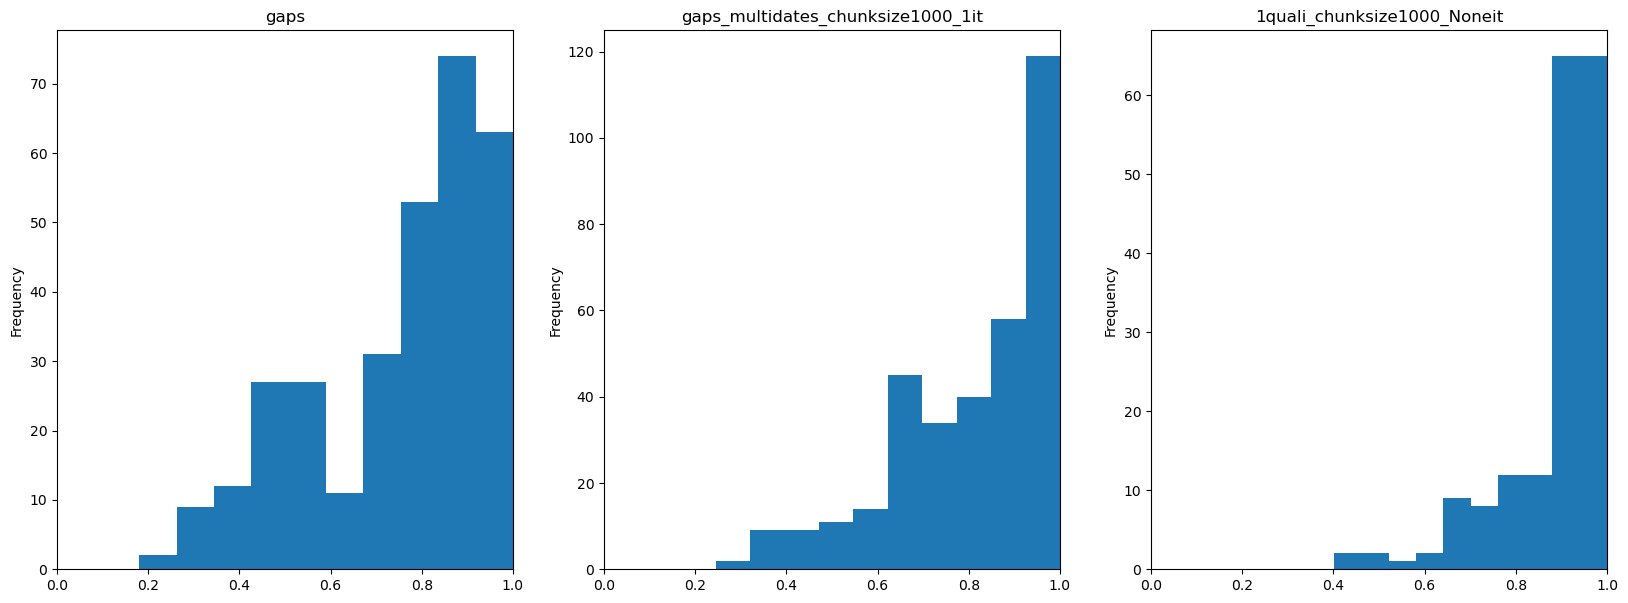

In [19]:
fig, axes = plt.subplots(1,3, figsize=(20, 7),sharey=False, sharex=False)

for i, df in enumerate([matched_df1, matched_df2, matched_df3]):
    df.groupby("ext_match_id_sim")["match_sim"].mean().plot(kind="hist", ax=axes[i])
    axes[i].set_title(keys[i])
    axes[i].set_xlim(0,1)

In [20]:
def make_sim_results_df(df, sim_cols, keyname, key):
    df = df.copy()
    appeal_results = []
    sim_results = []

    # group by appealCode + extracted row + quanti/quali
    group = df.groupby(["appealCode", "ext_match_id_sim", "quanti"])

    # average similarity per appealCode & quanti/quali split
    sim_per_appeal = (
        group[sim_cols].mean()
        .groupby(["appealCode", "quanti"]).mean()
        .reset_index()
    )

    # split quanti / quali
    sim_quanti = sim_per_appeal[sim_per_appeal["quanti"]=="quanti"].drop(columns="quanti")
    sim_quali = sim_per_appeal[sim_per_appeal["quanti"]=="quali"].drop(columns="quanti")

    # average impactValue error per appeal (only quanti)
    valerr_per_appeal = (
        df[df["quanti"]=="quanti"]
        .groupby("appealCode")[["impactValue_error"]]
        .mean()
        .reset_index()
    )

    # number of exact value matches
    exact_matches_value = (df["impactValue_error"] < 0.01).sum()

    # ---- build per appealCode tidy ----
    if not sim_quanti.empty:
        tmp_quanti = (
            sim_quanti.merge(valerr_per_appeal, on="appealCode", how="left")
            .assign(key=key, ext_type="quanti")
        )
        appeal_results.append(tmp_quanti)

    if not sim_quali.empty:
        tmp_quali = sim_quali.assign(
            impactValue_error=np.nan,  # no value error for quali
            key=key,
            ext_type="quali"
        )
        appeal_results.append(tmp_quali)

    # ---- build per similarity column tidy ----
    if not sim_quanti.empty:
        avg_quanti = (
            sim_quanti[sim_cols].mean()
            .reset_index()
            .rename(columns={"index": "similarity_column", 0: "avg_similarity"})
        )
        avg_quanti["exact_match"] = exact_matches_value
        avg_quanti[keyname] = key
        avg_quanti["ext_type"] = "quanti"
        sim_results.append(avg_quanti)

    if not sim_quali.empty:
        avg_quali = (
            sim_quali[sim_cols].mean()
            .reset_index()
            .rename(columns={"index": "similarity_column", 0: "avg_similarity"})
        )
        avg_quali["exact_match"] = np.nan
        avg_quali[keyname] = key
        avg_quali["ext_type"] = "quali"
        sim_results.append(avg_quali)

    # final tidy DataFrames
    appeal_df = pd.concat(appeal_results, ignore_index=True)
    sim_df = pd.concat(sim_results, ignore_index=True)
    return appeal_df, sim_df

In [21]:
from src.sanity_checks import flag_remove_cat
remove_cats = ["DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
matched_df1["flag_remove_cat"] = matched_df1.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df2["flag_remove_cat"] = matched_df2.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df3["flag_remove_cat"] = matched_df3.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [22]:
# similarity columns
accuracy_cols = [
    "hazards", "iso3_code", "startYear", "startMonth", "startDay",
    "endYear", "endMonth", "endDay", "impactSubtype", "impactUnit",
    "geometry", "impactValue","match"
]
sim_cols = [col + "_sim" for col in accuracy_cols]
value_error_th = 0.1
sim_th = 0.6
filter_flags = ["flag_unit_nonstd", "flag_remove_cat"]#["flag_unit_nonstd""flag_percent"

appeal_results = []
sim_results = []
for i, df in enumerate([matched_df1, matched_df2, matched_df3], start=1):
    df_filter_flags = filter_by_flags(df, flag_filters=filter_flags)
    df_filter_sim = filter_matches(df_filter_flags, value_error_th=value_error_th, sim_th=sim_th)
    appeal_df, sim_df = make_sim_results_df(df, keyname="filter", key="raw", sim_cols=sim_cols)
    appeal_df[keys_name] = keys[i-1]
    sim_df[keys_name] = keys[i-1]
    appeal_results.append(appeal_df)
    sim_results.append(sim_df)
    appeal_df, sim_df = make_sim_results_df(df_filter_flags, keyname="filter", key="filtered_flags", sim_cols=sim_cols)
    appeal_df[keys_name] = keys[i-1]
    sim_df[keys_name] = keys[i-1]
    appeal_results.append(appeal_df)
    sim_results.append(sim_df)
    appeal_df, sim_df = make_sim_results_df(df_filter_sim, keyname="filter", key="filtered_sim", sim_cols=sim_cols)
    appeal_df[keys_name] = keys[i-1]
    sim_df[keys_name] = keys[i-1]
    appeal_results.append(appeal_df)
    sim_results.append(sim_df)


# final tidy DataFrames
appeal_df = pd.concat(appeal_results, ignore_index=True)
sim_df = pd.concat(sim_results, ignore_index=True)

# log-transformed impact value error (only valid for quanti)
if "impactValue_error" in appeal_df.columns:
    appeal_df["log_impactValue_error"] = np.log10(appeal_df["impactValue_error"])


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [23]:
def add_avg_line(val_df, ax, hue_col, yvar, value_col, hue_vars, palette):
    for j, var in enumerate(hue_vars):
        mean_val = val_df[val_df[hue_col] == var].groupby(yvar)[value_col].mean().mean()
        #mean_val = df[(df[yvar] == "Overall average") & (df[hue_col] == var) & (df[subplot_col] == val)][value_col].values[0]
        ax.axvline(mean_val, color=palette[j], linestyle="--", linewidth=2)
        ax.text(
            mean_val, 2+2*j, f"Average {var}: {mean_val:.2f}"
            , color=palette[j], ha="left", va="center", backgroundcolor="white"
        )
    return ax

def add_avg_text(ax, x_offset=0.01):
    for bar in ax.patches:
        width = bar.get_width()
        if width == 0 or np.isnan(width):  # skip empty / dummy bars
            continue
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + x_offset, y, f"{width:.2f}", va='center')
    return ax

def plot_avg_sim(df, subplot_col, hue_col, yvar, xlabel="%", value_col="value",subplot_vars=None, hue_vars=None, palette=None, add_avg=True, add_text=True,fig=None):
    if not subplot_vars:
        subplot_vars = df[subplot_col].unique()
    if not hue_vars:
        hue_vars = df[hue_col].unique()
    if not palette:
        palette = np.repeat(sns.color_palette("colorblind", len(hue_vars), as_cmap=True), 2)
    if fig is None:
        fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    else:
        ax = fig.get_axes()
    for i, val in enumerate(subplot_vars):
        val_df = df[df[subplot_col] == val]
        ipal = palette[i*len(hue_vars) : (i+1)*len(hue_vars)]
        sns.barplot(
            data=val_df,
            x=value_col, y=yvar,
            hue=hue_col,
            hue_order=hue_vars,
            palette=ipal,
            width=0.7,
            ax=ax[i]
        )

        #add average coverage line
        if add_avg:
            ax[i] = add_avg_line(val_df, ax[i], hue_col, yvar, value_col, hue_vars, ipal)
        if add_text:
            ax[i] = add_avg_text(ax[i])

        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax


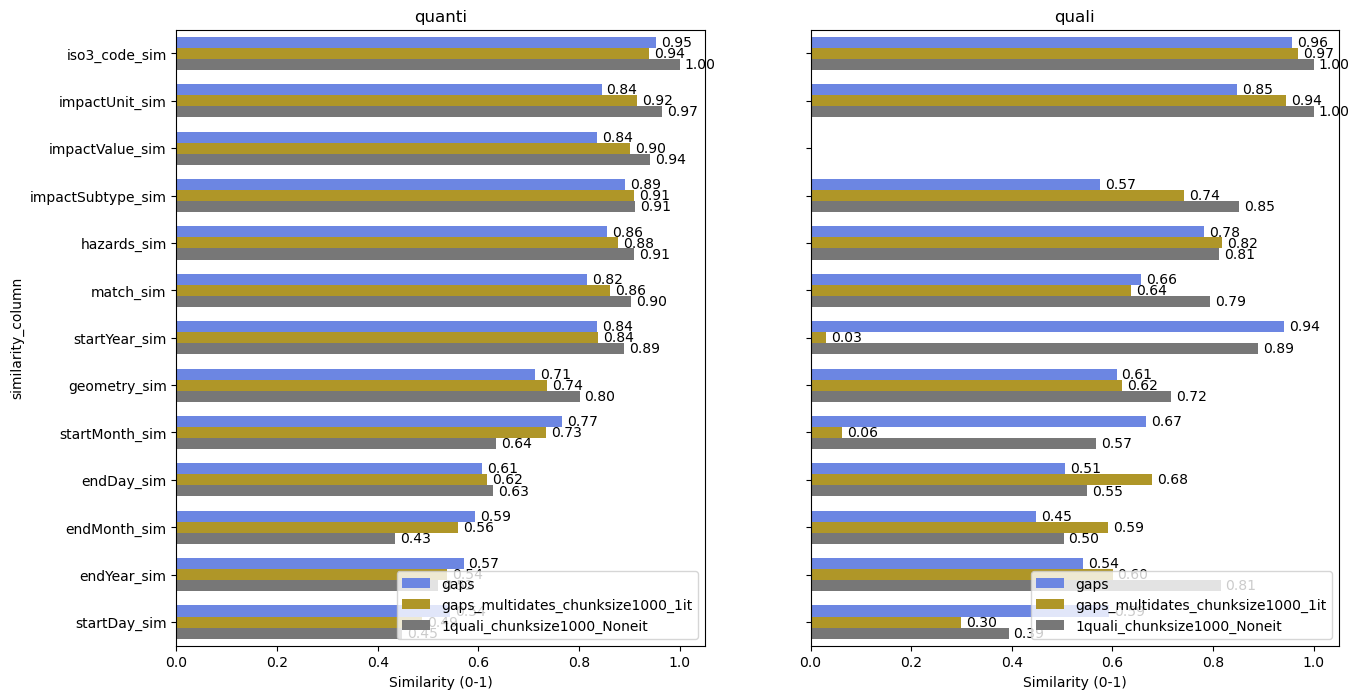

In [24]:
plot_df = sim_df[sim_df["filter"] == "filtered_flags"].sort_values(by="avg_similarity", ascending=False)
palette = ["#587BF6", "#C5A412","#777777","#587BF6", "#C5A412","#777777"]
subplot_col = "ext_type"
subplot_vars = ["quanti", "quali"]
hue_col =keys_name
yvar = "similarity_column"
hue_vars = keys
fig, ax = plot_avg_sim(plot_df, subplot_col=subplot_col, hue_col=hue_col, yvar=yvar, subplot_vars=subplot_vars, hue_vars=hue_vars, palette=palette,xlabel="Similarity (0-1)", value_col="avg_similarity", add_text=True, add_avg=False)
fig.savefig(DATA_FIGURE / f"similarity_by_extraction_type_{res_savename_ext}_filtered_flags_v270326.png", dpi=300, bbox_inches="tight")

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_41809/2211828966.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(["Match similarity"])


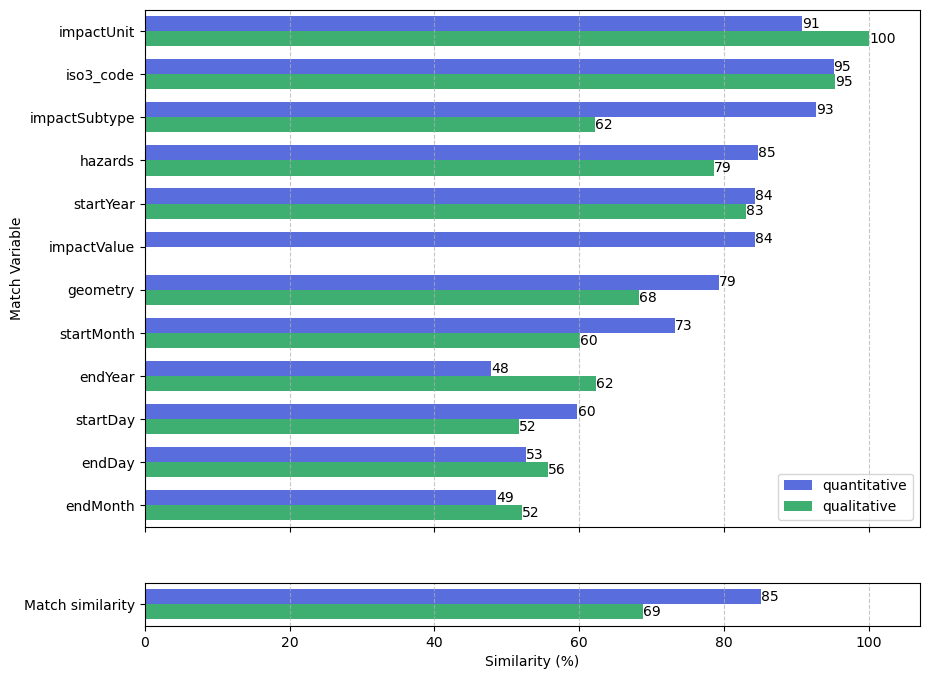

In [13]:
ikey = "fixed_impact_desc3"
filter = "filtered_flags"
plot_df = sim_df[(sim_df[keys_name] == ikey) & (sim_df["filter"] == filter)].sort_values(by="avg_similarity", ascending=False)
plot_df_avg = plot_df[plot_df["similarity_column"] == "match_sim"]
plot_df =  plot_df[plot_df["similarity_column"] != "match_sim"]
palette = ["#435EF3", "#2bc26f"]
subplot_col = keys_name
subplot_vars = [ikey]
hue_col ="ext_type"
yvar = "similarity_column"
hue_vars = ["quantitative", "qualitative"]
plot_df["similarity_column"] = plot_df["similarity_column"].str.replace("_sim", "") #for plotting
plot_df["avg_similarity"] = plot_df["avg_similarity"]*100
plot_df_avg["avg_similarity"] = plot_df_avg["avg_similarity"]*100
plot_df["ext_type"] = plot_df["ext_type"].str.replace("quanti", "quantitative")
plot_df["ext_type"] = plot_df["ext_type"].str.replace("quali", "qualitative")
plot_df_avg["ext_type"] = plot_df_avg["ext_type"].str.replace("quanti", "quantitative")
plot_df_avg["ext_type"] = plot_df_avg["ext_type"].str.replace("quali", "qualitative")

fig, axes = plt.subplots(2,1, figsize=(10, 8),sharey=False, sharex=True, gridspec_kw={'height_ratios': [12, 1]})
fig, axes = plot_avg_sim(plot_df, subplot_col=subplot_col, hue_col=hue_col, yvar=yvar, subplot_vars=subplot_vars, hue_vars=hue_vars, palette=palette,xlabel="Similarity (0-1)", value_col="avg_similarity", add_text=True, add_avg=False, fig=fig)
#add average match
sns.barplot(
    data=plot_df_avg,
    x="avg_similarity", y=yvar,
    hue=hue_col,
    hue_order=hue_vars,
    palette=palette,
    width=0.7,
    ax=axes[1]
)

#add grid
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
axes[1].set_xlim(0, 107)
axes[1] = add_avg_text(axes[1])
axes[1].set_yticklabels(["Match similarity"])
axes[0].set_ylabel("Match Variable")
axes[1].set_xlabel("Similarity (%)")
axes[0].set_title("")
axes[1].set_ylabel("")
axes[1].get_legend().remove()
fig.savefig(DATA_FIGURE / f"avg_sim_by_{yvar}_{subplot_col}_{filter}_{ikey}_{match_type}_{model.replace(model, MODEL_NAMES_MAP[model])}.png", bbox_inches="tight", dpi=300)